## Introducción

**Dataset:** Breast Cancer Wisconsin (Diagnostic)

**Fuente:** Scikit-learn — `load_breast_cancer`

**Liga:** https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html

El dataset **Breast Cancer Wisconsin** contiene información de muestras de tumores de mama obtenida a partir de imágenes digitalizadas. Incluye diferentes características numéricas de los núcleos celulares, como radio, textura, perímetro, área y suavidad, que permiten analizar y clasificar los tumores como **malignos o benignos**.

# Parte 1. Descripción del dataset

## Registros

Cada registro representa una muestra de un tumor de mama obtenida a partir del análisis de imágenes digitalizadas de células.

## Variable objetivo

La variable objetivo es `target`, que indica el diagnóstico de la muestra:

- **0 = Maligno**
- **1 = Benigno**

## Variables predictoras

Las variables predictoras son características numéricas de los núcleos celulares, como radio, textura, perímetro, área, suavidad, concavidad y simetría, entre otras.

## Preguntas de análisis

**Análisis supervisado:**  
¿Es posible predecir si un tumor es maligno o benigno a partir de sus características numéricas?

**Análisis no supervisado:**  
¿Es posible identificar grupos de tumores con características similares sin utilizar su diagnóstico como referencia?

# Parte 2. Carga y revisión inicial de los datos

En esta parte se carga el dataset y se revisa su estructura para conocer el número de registros, las variables disponibles, sus tipos de datos, valores faltantes, registros duplicados y la distribución de la variable objetivo.

### 2.1 Cargar el dataset

In [2]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### 2.2 Número de registros y variables

In [4]:
print("Numero de registros:", df.shape[0])
print("Numero de variables:", df.shape[1])

Numero de registros: 569
Numero de variables: 31


### 2.3 Variables disponibles

In [5]:
df.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'target'],
      dtype='object')

###2.4 Tipos de datos

In [6]:
df.dtypes

,0
mean radius,float64
mean texture,float64
mean perimeter,float64
mean area,float64
mean smoothness,float64
mean compactness,float64
mean concavity,float64
mean concave points,float64
mean symmetry,float64
mean fractal dimension,float64


###2.5 Valores faltantes

In [7]:
df.isnull().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


### 2.6 Registros duplicados

In [9]:
df.duplicated().sum()

np.int64(0)

### 2.7 Distribucion de la variable objetivo

In [10]:
df["target"].value_counts()

,count
target,
1,357
0,212


In [11]:
df["target"].value_counts().rename(index={
    0: "Maligno",
    1: "Benigno"
})

,count
target,
Benigno,357
Maligno,212


### 2.8 Limpieza de los datos.

Después de revisar el dataset, no se encontraron valores faltantes ni registros duplicados. Además, las variables predictoras ya se encuentran en formato numérico, por lo que no es necesario eliminar registros ni realizar conversiones de tipo.

Para el desarrollo de los modelos se conservarán las **30 variables numéricas predictoras** y la variable target como etiqueta de clasificación.

# Parte 3. Preparación y escalamiento de los datos

## 3.1 Separación de variables

Se utilizarán las 30 variables numéricas del dataset como variables predictoras. La variable `target` se separará para utilizarse únicamente en la evaluación supervisada y posteriormente para comparar las clases reales con los clusters obtenidos.

In [12]:
X = df.drop(columns=["target"])
y = df["target"]

# Copia de las etiquetas reales
y_real = y.copy()

print("Variables predictoras:")
print(X.shape)
print("\nVariable objetivo:")
print(y.shape)

Variables predictoras:
(569, 30)

Variable objetivo:
(569,)


## 3.2 Escalamiento de las variables

Se utilizará `StandardScaler` para que las variables tengan una escala comparable. Esta versión escalada se utilizará posteriormente para el análisis con K-Means.

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


## 3.3 Importancia del escalamiento

El escalamiento es importante porque **SVM** utiliza distancias para encontrar la frontera que separa las clases y **K-Means** utiliza distancias para asignar las observaciones a los clusters.

Si una variable tiene valores mucho mayores que las demás, puede tener una influencia excesiva sobre ambos modelos. Por esta razón se utiliza `StandardScaler` para colocar las variables en una escala similar.

# Parte 4. División de los datos

## 4.1 Separación en entrenamiento y prueba

Para evaluar el modelo supervisado, los datos se dividirán en **80 % para entrenamiento** y **20 % para prueba**. Se utilizará una semilla fija para que la partición sea reproducible y `stratify=y` para conservar la proporción de tumores malignos y benignos en ambos conjuntos.

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (455, 30)
Datos de prueba: (114, 30)


## 4.2 Importancia de la división

Esta división permite entrenar el modelo con una parte de los datos y evaluarlo posteriormente con observaciones que no fueron utilizadas durante el entrenamiento.

De esta manera, se puede medir qué tan bien el clasificador puede generalizar y realizar predicciones sobre datos nuevos.

# Parte 5. Modelos SVM

## 5.1 Entrenamiento de los modelos

Se entrenarán dos modelos SVM: uno utilizando un **kernel lineal** y otro utilizando un **kernel RBF**. En ambos casos se utilizará un `Pipeline` que incluye `StandardScaler`, evitando que el escalamiento utilice información del conjunto de prueba.

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Modelo 1: Kernel Lineal
svm_lineal = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='linear'))
])

# Modelo 2: Kerner RBF
svm_rbf = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf'))
])

# Entrenamiento de los modelos
svm_lineal.fit(X_train, y_train)
svm_rbf.fit(X_train, y_train)

#Predicciones
y_pred_lineal = svm_lineal.predict(X_test)
y_pred_rbf = svm_rbf.predict(X_test)

## 5.2 Evaluación de los modelos

Los modelos serán evaluados mediante **accuracy, precision, recall y F1-score**.

Como el dataset contiene únicamente dos clases, se utilizará una evaluación binaria. Se tomará la clase **maligna (0)** como clase positiva, ya que es la clase de mayor interés para identificar correctamente.

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

resultados = pd.DataFrame({
    "Modelo SVM": ["Modelo 1", "Modelo 2"],
    "Kernel": ["Lineal", "RBF"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lineal),
        accuracy_score(y_test, y_pred_rbf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lineal, pos_label=0),
        precision_score(y_test, y_pred_rbf, pos_label=0)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lineal, pos_label=0),
        recall_score(y_test, y_pred_rbf, pos_label=0)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_lineal, pos_label=0),
        f1_score(y_test, y_pred_rbf, pos_label=0)
    ]
})

resultados.round(4)

,Modelo SVM,Kernel,Accuracy,Precision,Recall,F1-score
0,Modelo 1,Lineal,0.9737,0.9535,0.9762,0.9647
1,Modelo 2,RBF,0.9825,0.9762,0.9762,0.9762


# Parte 6. Matriz de confusión

## 6.1 Matriz de confusión del mejor modelo

De acuerdo con los resultados obtenidos, el modelo con **kernel RBF** presentó el mejor desempeño general, por lo que se utilizará para generar la matriz de confusión.

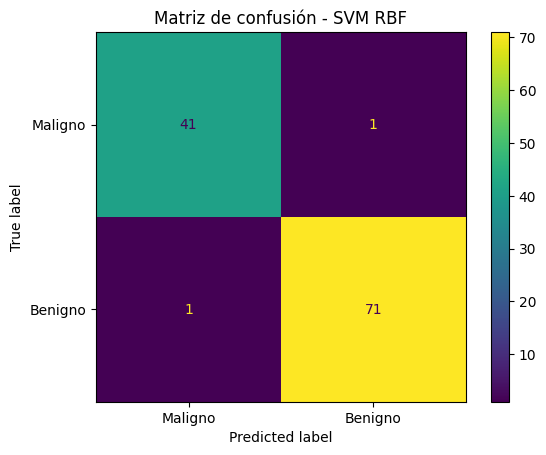

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rbf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Maligno", "Benigno"]
)

disp.plot()
plt.title("Matriz de confusión - SVM RBF")
plt.show()

## 6.2 Interpretación

El modelo clasificó correctamente **41 tumores malignos** y **71 tumores benignos**.

Solo cometió dos errores: un tumor maligno fue clasificado como benigno y un tumor benigno fue clasificado como maligno. Por lo tanto, ambas clases fueron distinguidas con un desempeño muy alto y no se observa una diferencia importante en la dificultad para clasificarlas.

No basta con revisar únicamente la **accuracy**, ya que esta solo muestra el porcentaje total de predicciones correctas. La matriz de confusión permite identificar específicamente qué tipos de errores está cometiendo el modelo, lo cual es especialmente importante cuando confundir un tumor maligno con uno benigno puede ser más relevante que cometer el error contrario.

# Parte 7. Ajuste de hiperparámetros

## 7.1 Comparación de valores de C

Se compararán dos valores del hiperparámetro `C` en el modelo SVM con kernel RBF para observar cómo cambia su desempeño.

In [23]:
# Modelo con C = 0.1
svm_c01 = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=0.1))
])

# Modelo con C = 10
svm_c10 = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=10))
])

svm_c01.fit(X_train, y_train)
svm_c10.fit(X_train, y_train)

pred_c01 = svm_c01.predict(X_test)
pred_c10 = svm_c10.predict(X_test)

### 7.2 Comparación del desempeño

In [24]:
comparacion_c = pd.DataFrame({
    "C": [0.1, 10],
    "Accuracy": [
        accuracy_score(y_test, pred_c01),
        accuracy_score(y_test, pred_c10)
    ],
    "Precision": [
        precision_score(y_test, pred_c01, pos_label=0),
        precision_score(y_test, pred_c10, pos_label=0)
    ],
    "Recall": [
        recall_score(y_test, pred_c01, pos_label=0),
        recall_score(y_test, pred_c10, pos_label=0)
    ],
    "F1-score": [
        f1_score(y_test, pred_c01, pos_label=0),
        f1_score(y_test, pred_c10, pos_label=0)
    ]
})

comparacion_c.round(4)

,C,Accuracy,Precision,Recall,F1-score
0,0.1,0.9474,0.9500,0.9048,0.9268
1,10.0,0.9737,0.9535,0.9762,0.9647


## 7.3 Interpretación de los hiperparámetros

El parámetro `C` controla cuánto penaliza SVM los errores de clasificación.

- Un **C pequeño** permite más errores y genera un margen más amplio, produciendo un modelo más simple.
- Un **C grande** intenta clasificar correctamente más observaciones, creando una frontera más ajustada y aumentando el riesgo de sobreajuste.

Por otro lado, en un kernel RBF, `gamma` controla qué tanta influencia tiene cada observación. Un `gamma` alto puede producir una frontera más compleja, mientras que un valor bajo genera una frontera más suave y general.

# Parte 8. Análisis no supervisado con K-Means

## 8.1 Evaluación de diferentes valores de k

Para identificar el número adecuado de clusters, se probarán valores de `k` entre 2 y 6. Se utilizarán el **método del codo** y el **silhouette score**.

K-Means se entrenará únicamente con las variables predictoras escaladas, sin utilizar la variable objetivo.

In [25]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inercias = []
silhouettes = []
valores_k = range(2, 7)

for k in valores_k:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    clusters = kmeans.fit_predict(X_scaled)

    inercias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, clusters))

### 8.2 Método del codo

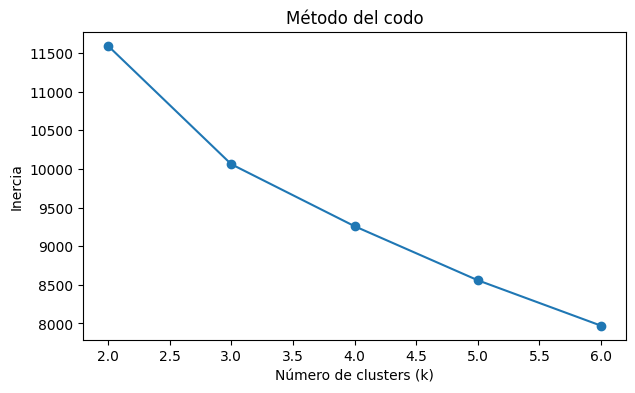

In [26]:
plt.figure(figsize=(7, 4))

plt.plot(valores_k, inercias, marker="o")

plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.title("Método del codo")

plt.show()

El método del codo analiza cómo disminuye la inercia al aumentar el número de clusters. Se busca un punto donde agregar más clusters deje de producir una mejora considerable.

### 8.3 Silhouette Score

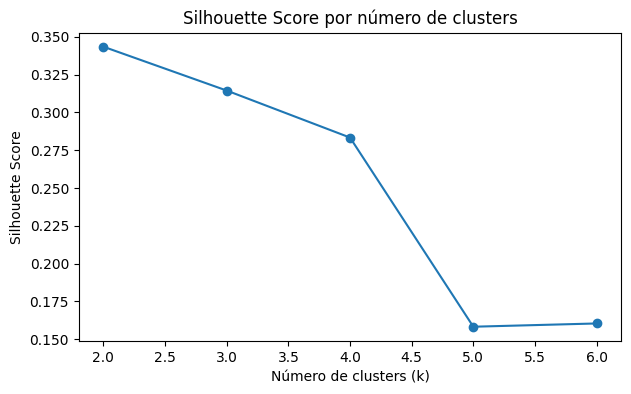

In [27]:
plt.figure(figsize=(7, 4))

plt.plot(valores_k, silhouettes, marker="o")

plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score por número de clusters")

plt.show()

### 8.4 Selección de k

De acuerdo con los resultados, se selecciona **k = 2**, ya que presenta el mayor **silhouette score** y el método del codo también muestra una reducción importante de la inercia en los primeros grupos.

Esto indica que dividir las observaciones en dos clusters produce una separación más clara que utilizar un número mayor de grupos.

In [28]:
kmeans_final = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

clusters = kmeans_final.fit_predict(X_scaled)

# Parte 9. Interpretación de los clusters

## 9.1 Tamaño y características promedio de cada cluster

Para analizar las diferencias entre los grupos obtenidos, se comparará el tamaño de cada cluster y el promedio de algunas de las características principales de los tumores.

In [29]:
# Copia de las variables originales
df_clusters = X.copy()

# Agregar el cluster asignado por K-Means
df_clusters["Cluster"] = clusters

variables_principales = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean concavity",
    "mean concave points"
]

resumen_clusters = df_clusters.groupby("Cluster")[variables_principales].mean()

# Agregar tamaño de cada cluster
resumen_clusters.insert(
    0,
    "Tamaño",
    df_clusters["Cluster"].value_counts().sort_index()
)

resumen_clusters.round(2)

,Tamaño,mean radius,mean texture,mean perimeter,mean area,mean concavity,mean concave points
Cluster,,,,,,,
0,375,12.43,18.26,79.82,486.77,0.04,0.03
1,194,17.41,21.28,115.45,979.86,0.18,0.09


## 9.2 Interpretación de los clusters

El **cluster 0** agrupa principalmente observaciones con menores valores de radio, perímetro, área y concavidad. En general, representa muestras con características celulares de menor tamaño y menor irregularidad.

El **cluster 1** presenta valores mayores en varias de estas características, especialmente en el tamaño del tumor y en medidas relacionadas con la concavidad. Esto indica que las muestras de este grupo tienden a presentar estructuras más grandes e irregulares.

Por lo tanto, K-Means parece separar las observaciones principalmente de acuerdo con diferencias en el **tamaño y la forma de las células**. Por ahora, estos grupos no deben interpretarse directamente como tumores malignos o benignos, ya que la variable objetivo no fue utilizada para crear los clusters.

# Parte 10. Visualización de clusters con PCA

## 10.1 Reducción a dos dimensiones

Debido a que el dataset contiene 30 variables predictoras, se utilizará **PCA** para reducir la información a dos componentes principales y poder visualizar los grupos obtenidos con K-Means.

In [30]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(
    X_pca,
    columns=["Componente 1", "Componente 2"]
)

df_pca["Cluster"] = clusters

df_pca.head()

,Componente 1,Componente 2,Cluster
0,9.192837,1.948583,1
1,2.387802,-3.768172,1
2,5.733896,-1.075174,1
3,7.122953,10.275589,1
4,3.935302,-1.948072,1


### 10.2 Gráfica de los clusters

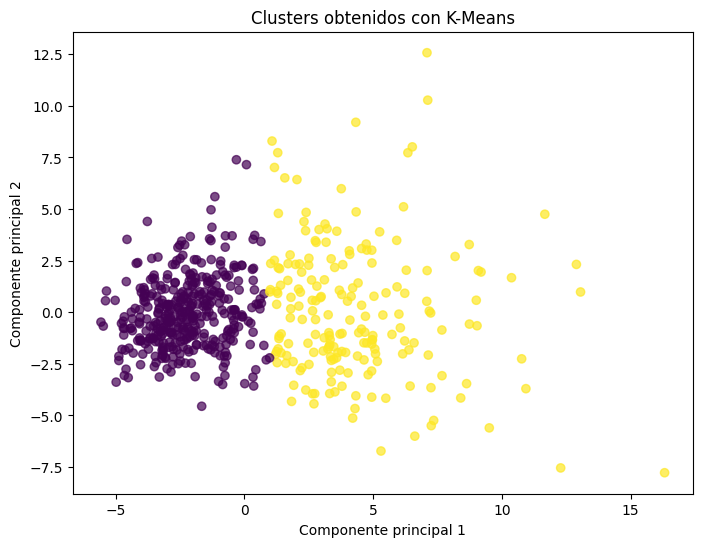

In [31]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df_pca["Componente 1"],
    df_pca["Componente 2"],
    c=df_pca["Cluster"],
    cmap="viridis",
    alpha=0.7
)

plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.title("Clusters obtenidos con K-Means")
plt.show()

La gráfica permite observar la distribución de los dos clusters después de reducir las 30 variables originales a dos componentes principales. Se puede apreciar una separación entre los grupos, aunque algunas observaciones se encuentran cercanas o mezcladas en la zona intermedia.

### 10.3 Comparación visual con las clases reales

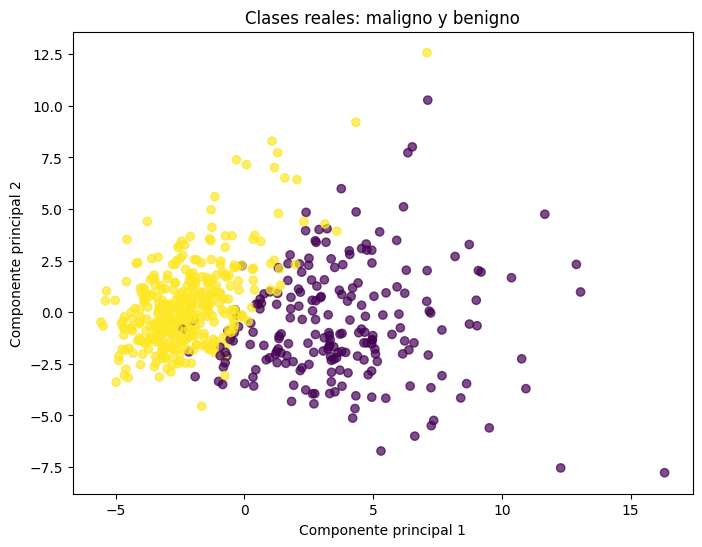

In [32]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df_pca["Componente 1"],
    df_pca["Componente 2"],
    c=y_real,
    cmap="viridis",
    alpha=0.7
)

plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.title("Clases reales: maligno y benigno")
plt.show()

# Parte 11. Comparación de clusters con las clases reales

## 11.1 Tabla de comparación

Para comparar los grupos obtenidos por K-Means con las clases reales, se utilizará una tabla de contingencia. Las etiquetas reales se emplean únicamente para esta comparación final y no para entrenar K-Means.

In [33]:
comparacion_clusters = pd.crosstab(
    y_real,
    clusters,
    rownames=["Clase real"],
    colnames=["Cluster"]
)

comparacion_clusters

Cluster,0,1
Clase real,,
0,36,176
1,339,18


## 11.2 Interpretación

Se observa una **correspondencia parcial** entre los clusters y las clases reales. Uno de los grupos contiene principalmente tumores benignos, mientras que el otro concentra una mayor cantidad de tumores malignos.

Sin embargo, algunas observaciones aparecen mezcladas entre ambos grupos, por lo que los clusters no reproducen exactamente las etiquetas originales.

Esto ocurre porque **K-Means no conoce el diagnóstico real** de cada tumor. El algoritmo agrupa las observaciones únicamente de acuerdo con su similitud y distancia en el espacio de variables, mientras que las clases maligno y benigno corresponden a una etiqueta previamente conocida.

Por esta razón, los clusters pueden reflejar patrones naturales de tamaño, forma o irregularidad de los tumores sin coincidir perfectamente con las clases reales.

# Parte 12. Conclusión

El enfoque **supervisado con SVM** presentó resultados más fáciles de interpretar, ya que permitió comparar directamente las predicciones con las clases reales de tumores malignos y benignos mediante métricas como accuracy, precision, recall y F1-score.

SVM permitió construir un modelo capaz de **predecir una clase conocida** a partir de las características de cada tumor. Además, el ajuste de hiperparámetros mostró que modificar `C` puede afectar el desempeño y la capacidad de generalización del modelo.

Por otro lado, **K-Means** permitió identificar grupos naturales sin utilizar el diagnóstico de los tumores. Los clusters mostraron patrones relacionados principalmente con diferencias en el **tamaño, forma e irregularidad** de las muestras. Aunque existió cierta correspondencia con las clases reales, algunos tumores quedaron mezclados entre los grupos.

Una limitación de K-Means es que sus agrupamientos dependen de la distancia entre las observaciones y no necesariamente representan las clases reales. Además, la visualización mediante PCA reduce las 30 variables a solo dos componentes, por lo que parte de la información original puede perderse.

En conclusión, **SVM sería adecuado cuando existen etiquetas conocidas y se busca predecir una clase**, mientras que **K-Means sería útil cuando no existen etiquetas y se desea explorar patrones o estructuras presentes en los datos**.